# Wave Equation

The second-order wave equation governs the propagation of mechanical waves, sound, and electromagnetic fields:

$$\frac{\partial^2 u}{\partial t^2} = c^2\,\nabla^2 u$$

Because `solve_ivp` requires a first-order system, we split this into two coupled equations by introducing the velocity field $u_t = \partial u/\partial t$:

$$\frac{\partial u}{\partial t} = u_t \qquad \frac{\partial u_t}{\partial t} = c^2\,\nabla^2 u$$

We solve a 1D standing wave problem: a string fixed at both ends, plucked into a sinusoidal shape and released from rest. The analytical solution is $u(x,t) = \cos(\pi c t)\sin(\pi x)$.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
# import sys; sys.path.insert(0, '..')   # adjust path to upde.py and equations.py
# run pip install -e . to install package
from upde import PDE, PDESystem, WaveEquation

Max error vs analytical: 4.07e-05


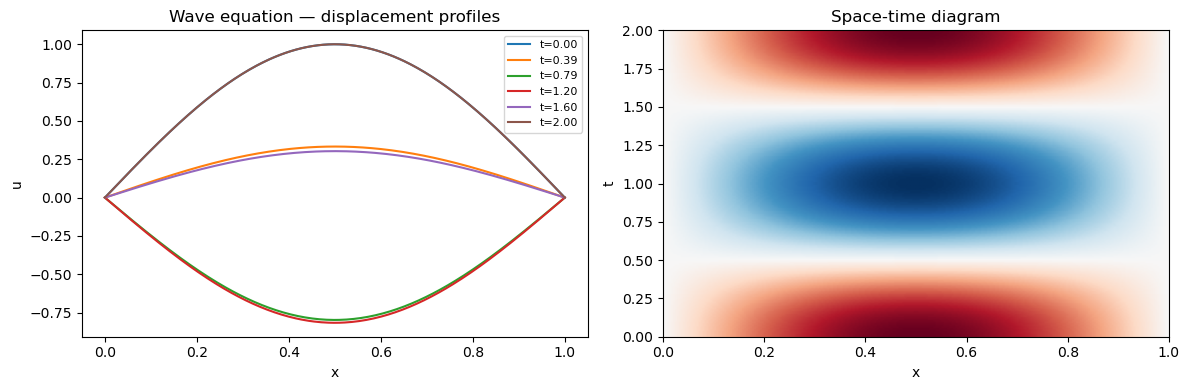

In [2]:
x = np.linspace(0, 1, 256)
c = 1.0

wave = WaveEquation('u', 'ut', x=x, speed=c)

# Fixed ends
wave.u.set_bc(side='left',  kind='dirichlet', value=0.0)
wave.u.set_bc(side='right', kind='dirichlet', value=0.0)
wave.ut.set_bc(side='left',  kind='dirichlet', value=0.0)
wave.ut.set_bc(side='right', kind='dirichlet', value=0.0)

# IC: sinusoidal displacement, zero velocity
wave.u.set_ic(lambda x: np.sin(np.pi * x))
wave.ut.set_ic(0.0)

t_eval = np.linspace(0, 2, 200)
sol = wave.solve(t_span=(0, 2), method='RK45',
                 t_eval=t_eval, rtol=1e-5, atol=1e-7)

# Compare to analytical solution u(x,t) = cos(pi*c*t)*sin(pi*x)
u_analytical = np.cos(np.pi * c * t_eval[None, :]) * np.sin(np.pi * x[:, None])
err = np.abs(sol.u - u_analytical).max()
print(f'Max error vs analytical: {err:.2e}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Snapshot at several times
for idx in np.linspace(0, len(t_eval)-1, 6).astype(int):
    axes[0].plot(x, sol.u[:, idx], label=f't={t_eval[idx]:.2f}')
axes[0].set_xlabel('x'); axes[0].set_ylabel('u')
axes[0].set_title('Wave equation — displacement profiles')
axes[0].legend(fontsize=8)

# Space-time diagram
axes[1].imshow(sol.u.T, origin='lower', aspect='auto',
               extent=[0,1,0,2], cmap='RdBu_r', vmin=-1, vmax=1)
axes[1].set_xlabel('x'); axes[1].set_ylabel('t')
axes[1].set_title('Space-time diagram')

plt.tight_layout(); plt.show()
